In [ ]:
import kagglehub
data = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd               # Librería para manejo de dataframes
import numpy as np                # Librería para trabajar don datos matriciales
import matplotlib.pyplot as plt   # Librería de visualización
from nltk.tokenize import word_tokenize
from nltk import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import sentence_transformers
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from keras.utils import pad_sequences, to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed    # Importar las capas densas y LSTM
from tensorflow.keras.models import Sequential         # Importar modelo de clase secuencial
!pip install nltk tensorflow keras
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from tensorflow.keras.preprocessing.text import Tokenizer   # Importar clase de parada temparana
# Sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,accuracy_score, confusion_matrix, classification_report   # Importar métricas de validación
from sklearn.preprocessing import StandardScaler      # Importar objeto para realizar estandarización de variables

df = pd.read_csv("bbc_news_text_complexity_summarization.csv")
df.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


preparacion de datos

In [ ]:
print(df.shape)

(2127, 7)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
text,0
labels,0
no_sentences,0
Flesch Reading Ease Score,0
Dale-Chall Readability Score,0
text_rank_summary,0
lsa_summary,0


Index(['text', 'labels', 'no_sentences', 'Flesch Reading Ease Score',
       'Dale-Chall Readability Score', 'text_rank_summary', 'lsa_summary'],
      dtype='object')


<ipython-input-7-5dde1503b1e4>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')


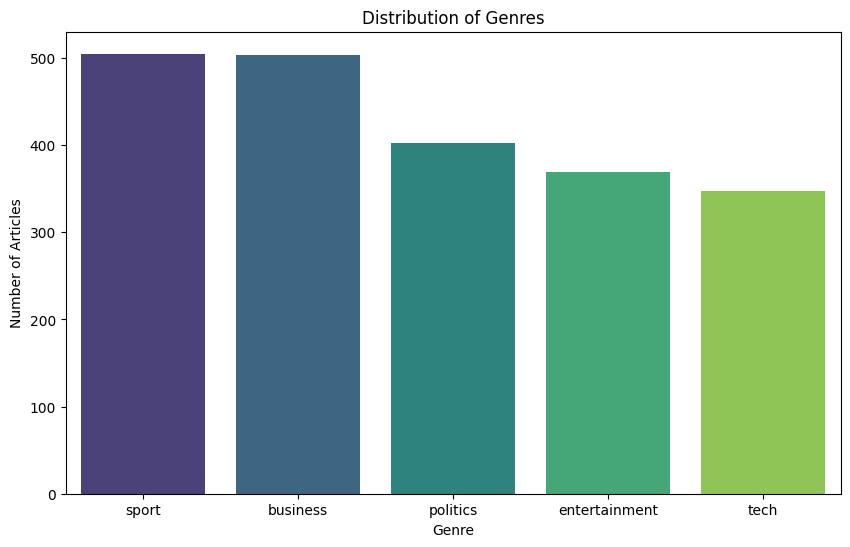

In [ ]:
print(df.columns)
genre_counts = df['labels'].value_counts()

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Distribution of Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Articles')
plt.show()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
<ipython-input-8-954e48b32c66>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='labels', y='num_words', data=avg_words_per_label, palette='viridis')


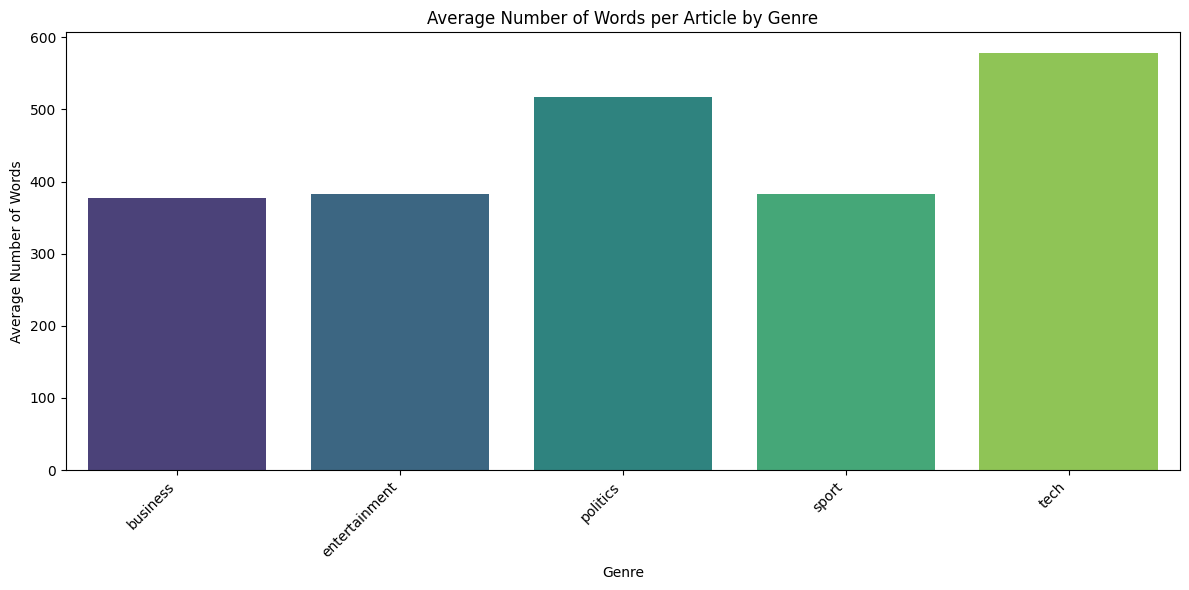

In [ ]:
nltk.download('punkt_tab')

df['num_words'] = df['text'].apply(lambda x: len(word_tokenize(x)))

avg_words_per_label = df.groupby('labels')['num_words'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='labels', y='num_words', data=avg_words_per_label, palette='viridis')
plt.title('Average Number of Words per Article by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Number of Words')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

<ipython-input-9-d64f84e199df>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='labels', y='num_sentences', data=df, palette='viridis')


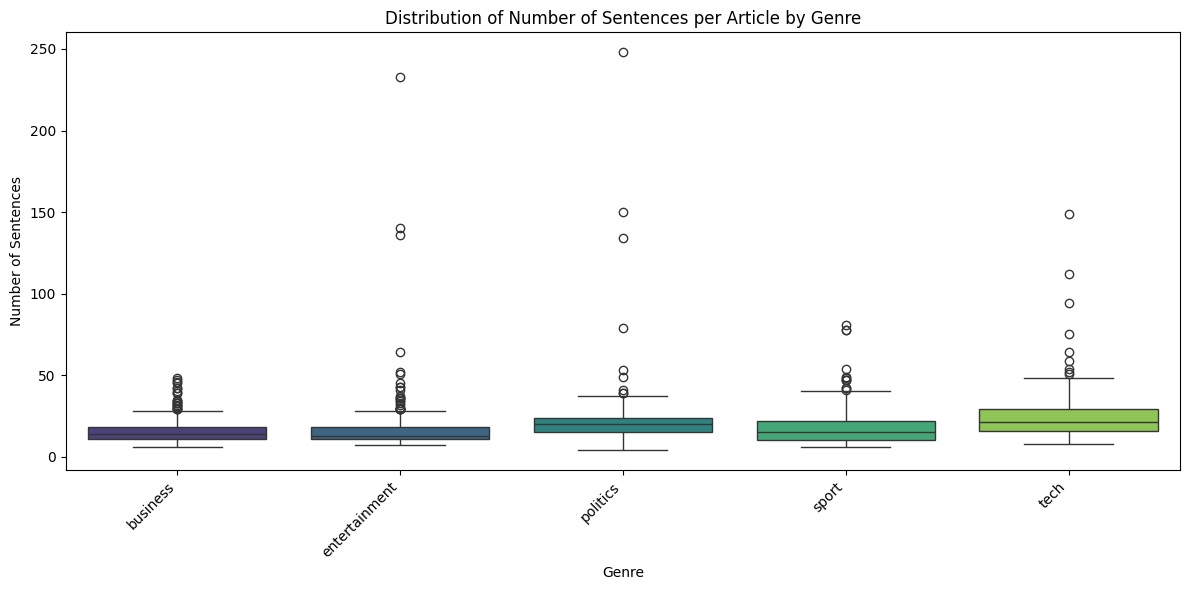

In [ ]:
# prompt: create a boxplot showing the number of sentences it has five different boxplot with each genre.

df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

plt.figure(figsize=(12, 6))
sns.boxplot(x='labels', y='num_sentences', data=df, palette='viridis')
plt.title('Distribution of Number of Sentences per Article by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Sentences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
!pip install sentence-transformers
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
#from tensorflow.keras.preprocessing.text import Tokenizer   # Importar clase de parada temparana
 # changed SentenceTransformer to sentence_transformers

PRETRAINED_SENTENCE_MODEL = "all-mpnet-base-v2"

# Seeds topics that the model will attempt to converge to
SEED_TOPICS_FLAG = False

# Umap params
UMAP_N_NEIGHBOURS = 15
UMAP_N_COMPONENTS = 5
RANDOM_SEED = 42

# hdbscan params
MIN_CLUSTER_SIZE = 15

# Representation model params
DIVERSITY = 0.5 # val in [0,1] specifying diversity of words in each topic

# Outlier reduction params
OUTLIER_THRESH = 0.2

In [ ]:
docs = df.loc[0].to_list()

from sentence_transformers import SentenceTransformer # Import the class

sentence_model = SentenceTransformer(PRETRAINED_SENTENCE_MODEL) # Use the class name
embeddings = sentence_model.encode(docs,show_progress_bar=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

def preprocess_function(example):
    return tokenizer(example, truncation=True)

tokenized_data = df["text"].apply(preprocess_function)

# Extract input_ids from the tokenized data
# The structure of tokenized_data might vary based on the tokenizer output.
# Assuming it's a list of dictionaries where each dictionary has 'input_ids'.
# You might need to inspect the structure of tokenized_data to confirm.
input_ids = [item['input_ids'] for item in tokenized_data]

# Pad sequences to a fixed length
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import the function

# Ensure max_sequence_length is defined (it is in your code)
max_sequence_length = 100

padded_input_ids = pad_sequences(input_ids, maxlen=max_sequence_length, padding='post', truncating='post', dtype='int32')

x = padded_input_ids # Now x is a NumPy array of integers
label_mapping = {label: i for i, label in enumerate(df["labels"].unique())}
y = df["labels"].map(label_mapping)
#print(y).value_counts()
# Split the prepared data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print(y.value_counts())

labels
3    505
0    503
2    403
1    369
4    347
Name: count, dtype: int64


defincion de modelo

In [ ]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
from tensorflow.keras.layers import Input, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from tensorflow.keras.layers import Embedding, MultiHeadAttention, LayerNormalization, Dropout, Dense, Input
from tensorflow.keras.models import Model
vocab_size = tokenizer.vocab_size

max_sequence_length = 100 # Example: you might need to pad/truncate sequences
embedding_dim = 64 # Example: dimension of the embedding space
num_heads = 4 # Example: number of attention heads
ff_dim = 128
num_layers = 2 # Example: dimension of the feed-forward network
dropout_rate = 0.1
class TokenAndPositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_sequence_length, vocab_size, embedding_dim):
        super().__init__()
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embedding_dim)
        self.pos_emb = Embedding(input_dim=max_sequence_length, output_dim=embedding_dim)

    def call(self, inputs):
        positions = tf.range(start=0, limit=tf.shape(inputs)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(inputs)
        return x + positions

# 2. Encoder Layer
class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, embedding_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embedding_dim),]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# 3. Build the Encoder Model
def build_encoder(max_sequence_length, vocab_size, embedding_dim, num_heads, ff_dim, num_layers=2, dropout_rate=0.1):
    inputs = Input(shape=(max_sequence_length,), dtype=tf.int32)
    x = TokenAndPositionalEmbedding(max_sequence_length, vocab_size, embedding_dim)(inputs)

    for _ in range(num_layers):
        # Pass the 'training' argument to the TransformerEncoderLayer's call method
        x = TransformerEncoderLayer(embedding_dim, num_heads, ff_dim, dropout_rate)(x, training=False) # Added training=False

    # You can add a pooling layer here to get a fixed-size representation of the sequence
    # For example, global average pooling or taking the representation of a special token
    # x = tf.reduce_mean(x, axis=1) # Example of global average pooling

    encoder_model = Model(inputs=inputs, outputs=x)
    return encoder_model


In [ ]:
#embeddings = bert_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state


In [ ]:
class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, embedding_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att1 = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim) # Masked self-attention
        self.att2 = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim) # Encoder-decoder attention
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embedding_dim),]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.layernorm3 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
        self.dropout3 = Dropout(rate)

    def call(self, inputs, encoder_output, training, look_ahead_mask):
        # Masked self-attention
        attn1 = self.att1(inputs, inputs, look_ahead_mask)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.layernorm1(inputs + attn1)

        # Encoder-decoder attention
        attn2 = self.att2(out1, encoder_output)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.layernorm2(out1 + attn2)

        # Feed-forward network
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        return self.layernorm3(out2 + ffn_output)

# 5. Build the Decoder Model
def build_decoder(max_sequence_length, vocab_size, embedding_dim, num_heads, ff_dim, num_layers=2, dropout_rate=0.1):
    inputs = Input(shape=(max_sequence_length,), dtype=tf.int32)
    encoder_outputs = Input(shape=(None, embedding_dim), dtype=tf.float32) # Shape should match encoder output

    x = TokenAndPositionalEmbedding(max_sequence_length, vocab_size, embedding_dim)(inputs)

    for _ in range(num_layers):
        # Need a way to create and pass the look_ahead_mask in the decoder layer
        # For simplicity in this basic example, we'll omit the mask here.
        # In a real implementation, you would generate the mask based on the inputs
        x = TransformerDecoderLayer(embedding_dim, num_heads, ff_dim, dropout_rate)(x, encoder_outputs, training=True, look_ahead_mask=None)

    # Add a final Dense layer for output prediction
    output = Dense(vocab_size, activation='softmax')(x) # Assuming output vocab size is the same as input

    decoder_model = Model(inputs=[inputs, encoder_outputs], outputs=output)
    return decoder_model

entrenamiento de modelo

In [ ]:
encoder = build_encoder(max_sequence_length, vocab_size, embedding_dim, num_heads, ff_dim, num_layers, dropout_rate)
decoder = build_decoder(max_sequence_length, vocab_size, embedding_dim, num_heads, ff_dim, num_layers, dropout_rate)

In [ ]:
encoder_output = encoder.output
pooled_output = tf.keras.layers.GlobalAveragePooling1D()(encoder_output)


# Add a classification head
num_classes = len(df["labels"].unique()) # Get the number of unique classes
classification_output = Dense(num_classes, activation='softmax')(pooled_output) # Use 'softmax' for multi-class classification

# Define the final classification model
classification_model = tf.keras.Model(inputs=encoder.inputs, outputs=classification_output)

#transformer_model = tf.keras.Model(inputs=encoder.inputs, outputs=decoder.outputs)

In [ ]:
classification_model.compile(optimizer=AdamW(learning_rate=1e-4), loss=SparseCategoricalCrossentropy(), metrics=[SparseCategoricalAccuracy()])
classification_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 100))
  warnings.warn(msg)


54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 573ms/step - loss: 1.6157 - sparse_categorical_accuracy: 0.2675 - val_loss: 1.4508 - val_sparse_categorical_accuracy: 0.4554
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 308ms/step - loss: 1.3636 - sparse_categorical_accuracy: 0.5487 - val_loss: 1.1687 - val_sparse_categorical_accuracy: 0.6854
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 304ms/step - loss: 0.9567 - sparse_categorical_accuracy: 0.8225 - val_loss: 0.7090 - val_sparse_categorical_accuracy: 0.8286
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 333ms/step - loss: 0.4505 - sparse_categorical_accuracy: 0.9340 - val_loss: 0.4252 - val_sparse_categorical_accuracy: 0.8826
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 374ms/step - loss: 0.1658 - sparse_categorical_accuracy: 0.9864 - val_loss: 0.3333 - val_sparse_categorical_accuracy: 0.9014
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 336ms/step - loss: 0.0760 - sparse_categorical_accuracy: 0.9925 - val_loss: 0.2998 - val_sparse_categorical_accuracy: 0.9014
Epoch 7/1

evaluacion

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = classification_model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 100))
  warnings.warn(msg)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step
Accuracy: 0.9107981220657277
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       104
           1       0.87      0.79      0.83        78
           2       0.93      0.95      0.94        73
           3       0.92      0.99      0.96        98
           4       0.88      0.92      0.90        73

    accuracy                           0.91       426
   macro avg       0.91      0.91      0.91       426
weighted avg       0.91      0.91      0.91       426



BERT model


In [ ]:
!pip install transformers tensorflow
from transformers import BertTokenizer, TFBertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import numpy as np
import tensorflow as tf # Ensure tensorflow is imported

# Load BERT tokenizer and model
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_classes)

# Prepare data for BERT
# BERT requires specific input format: input_ids, attention_mask, token_type_ids (optional)
def tokenize_data_bert(text):
    return bert_tokenizer(text, truncation=True, padding='max_length', max_length=max_sequence_length, return_tensors='tf')

# Apply tokenization to the text data
tokenized_data_bert = df["text"].apply(tokenize_data_bert)

# Combine the results into TensorFlow tensors
input_ids_bert = tf.concat([item['input_ids'] for item in tokenized_data_bert], axis=0)
attention_mask_bert = tf.concat([item['attention_mask'] for item in tokenized_data_bert], axis=0)

# Convert TensorFlow tensors to NumPy arrays for train_test_split
input_ids_bert_np = input_ids_bert.numpy()
attention_mask_bert_np = attention_mask_bert.numpy()

# Split data for BERT
# Pass the NumPy arrays to train_test_split
x_train_input_ids, x_test_input_ids, x_train_attention_mask, x_test_attention_mask, y_train_bert, y_test_bert = train_test_split(
    input_ids_bert_np,         # First array (input_ids)
    attention_mask_bert_np,    # Second array (attention_mask)
    y,                      # Third array (labels) - Should be a pandas Series or NumPy array
    test_size=0.2,
    random_state=42
)

# Convert split data back to TensorFlow tensors if needed for the model
# In this case, the BERT model expects dict of tensors, so we'll keep them as NumPy for now and convert just before training
x_train_bert = {'input_ids': tf.constant(x_train_input_ids), 'attention_mask': tf.constant(x_train_attention_mask)}
x_test_bert = {'input_ids': tf.constant(x_test_input_ids), 'attention_mask': tf.constant(x_test_attention_mask)}

# Ensure labels are also in a suitable format for TensorFlow training
y_train_bert_tf = tf.constant(y_train_bert, dtype=tf.int64)
y_test_bert_tf = tf.constant(y_test_bert, dtype=tf.int64)


# Compile the BERT model
bert_model.compile(
    optimizer="SGD",
    loss=SparseCategoricalCrossentropy(from_logits=True), # Use from_logits=True as the model outputs logits
    metrics=['accuracy']
)

# Train the BERT model
history_bert = bert_model.fit(
    x_train_bert,
    y_train_bert_tf, # Use the TensorFlow tensor for training
    epochs=3, # BERT often converges faster
    batch_size=16, # Smaller batch size is common for BERT
    validation_data=(x_test_bert, y_test_bert_tf) # Use the TensorFlow tensor for validation
)

# Evaluate the BERT model
y_pred_logits_bert = bert_model.predict(x_test_bert).logits
y_pred_bert = np.argmax(y_pred_logits_bert, axis=1)

accuracy_bert = accuracy_score(y_test_bert, y_pred_bert) # Use the NumPy version of y_test for evaluation
print(f"\nBERT Model Accuracy: {accuracy_bert}")
print("BERT Model Classification Report:")
print(classification_report(y_test_bert, y_pred_bert, target_names=label_mapping.keys())) # Use original labels for report



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
107/107 [==============================] - 2516s 23s/step - loss: 0.8080 - accuracy: 0.7166 - val_loss: 0.1747 - val_accuracy: 0.9507
Epoch 2/3
107/107 [==============================] - 2432s 23s/step - loss: 0.1425 - accuracy: 0.9641 - val_loss: 0.3433 - val_accuracy: 0.8897
Epoch 3/3
14/14 [==============================] - 183s 13s/step

BERT Model Accuracy: 0.9530516431924883
BERT Model Classification Report:
               precision    recall  f1-score   support

     business       1.00      0.86      0.92       104
entertainment       0.94      1.00      0.97        78
     politics       0.90      1.00      0.95        73
        sport       0.98      1.00      0.99        98
         tech       0.93      0.93      0.93        73

     accuracy                           0.95       426
    macro avg       0.95      0.96      0.95       426
 weighted avg       0.96      0.95      0.95       426

